In [18]:
import cv2
import matplotlib.pyplot as plt
import pandas as pd
import easyocr

from ultralytics import YOLO

from py_files.detection import extract_plate
from py_files.preprocessing import preprocess_plate
from py_files.ocr import recognize_plate

In [19]:
# Load models

model = YOLO("../models/best.pt")

reader = easyocr.Reader(
    ["en"],
    gpu=False
)

Using CPU. Note: This module is much faster with a GPU.


In [20]:
# Test image

image_path = "../data/cars/images/val/0a0a00b2fbe89a47.jpg"

In [21]:
# Detect license plate

plates = extract_plate(
    image_path,
    model
)

print(f"Detected plates: {len(plates)}")

if len(plates) == 0:
    raise ValueError("No license plate detected.")

plate = plates[0]


image 1/1 C:\Users\User\PycharmProjects\JupyterProject\notebooks\..\data\cars\images\val\0a0a00b2fbe89a47.jpg: 480x640 1 license_plate, 88.3ms
Speed: 2.8ms preprocess, 88.3ms inference, 0.9ms postprocess per image at shape (1, 3, 480, 640)
Detected plates: 1


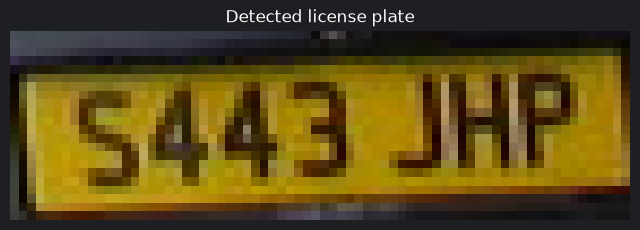

In [22]:
# Show detected plate

plt.figure(figsize=(8, 3))

plt.imshow(plate)

plt.title("Detected license plate")

plt.axis("off")

plt.show()

In [23]:
methods = [
    "baseline",
    "equalize",
    "clahe",
    "otsu",
    "adaptive",
    "clahe_otsu"
]

C:\Users\User\PycharmProjects\JupyterProject\.venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


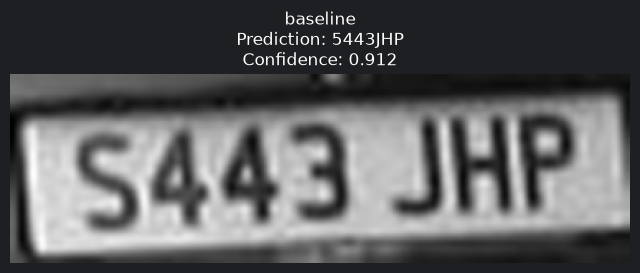

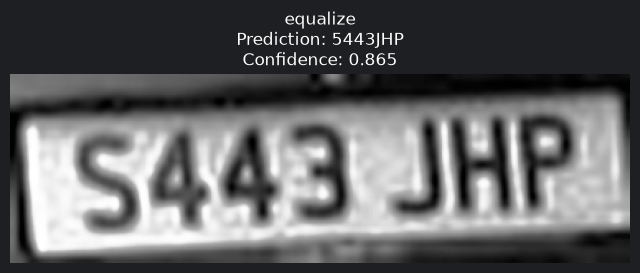

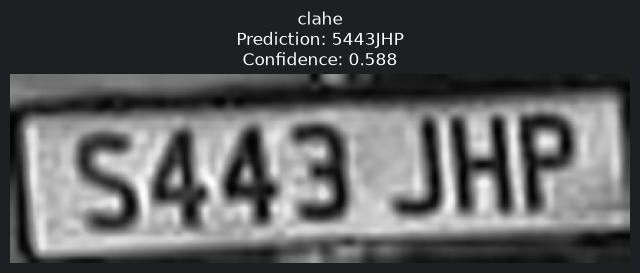

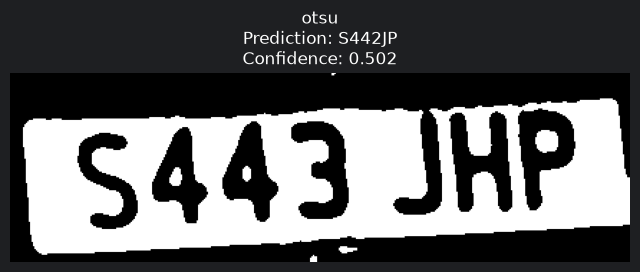

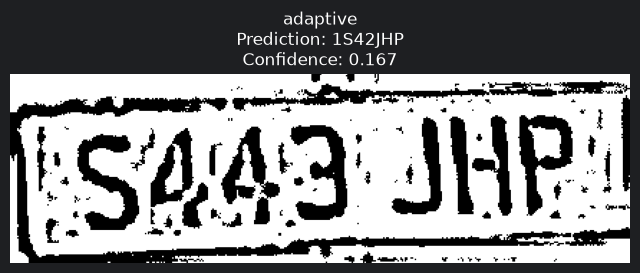

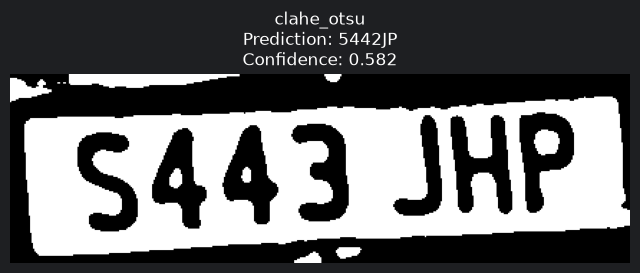

In [13]:
rows = []

for method in methods:
    processed = preprocess_plate(
        plate,
        method=method
    )

    text, conf = recognize_plate(
        processed,
        reader
    )

    rows.append({
        "Method": method,
        "Prediction": text,
        "Confidence": conf
    })

    plt.figure(figsize=(8, 3))

    plt.imshow(
        processed,
        cmap="gray"
    )

    plt.title(
        f"{method}\nPrediction: {text}\nConfidence: {conf:.3f}"
    )

    plt.axis("off")

    plt.show()

In [14]:
results = pd.DataFrame(rows)

results

,Method,Prediction,Confidence
0,baseline,5443JHP,0.911694
1,equalize,5443JHP,0.865446
2,clahe,5443JHP,0.588499
3,otsu,S442JP,0.502078
4,adaptive,1S42JHP,0.166561
5,clahe_otsu,5442JP,0.581961


In [15]:
results = results.sort_values(
    "Confidence",
    ascending=False
)

results

,Method,Prediction,Confidence
0,baseline,5443JHP,0.911694
1,equalize,5443JHP,0.865446
2,clahe,5443JHP,0.588499
5,clahe_otsu,5442JP,0.581961
3,otsu,S442JP,0.502078
4,adaptive,1S42JHP,0.166561


In [16]:
best_method = results.iloc[0]

print(f"Best preprocessing method: {best_method['Method']}")
print(f"Prediction: {best_method['Prediction']}")
print(f"Confidence: {best_method['Confidence']:.3f}")

Best preprocessing method: baseline
Prediction: 5443JHP
Confidence: 0.912


C:\Users\User\PycharmProjects\JupyterProject\.venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


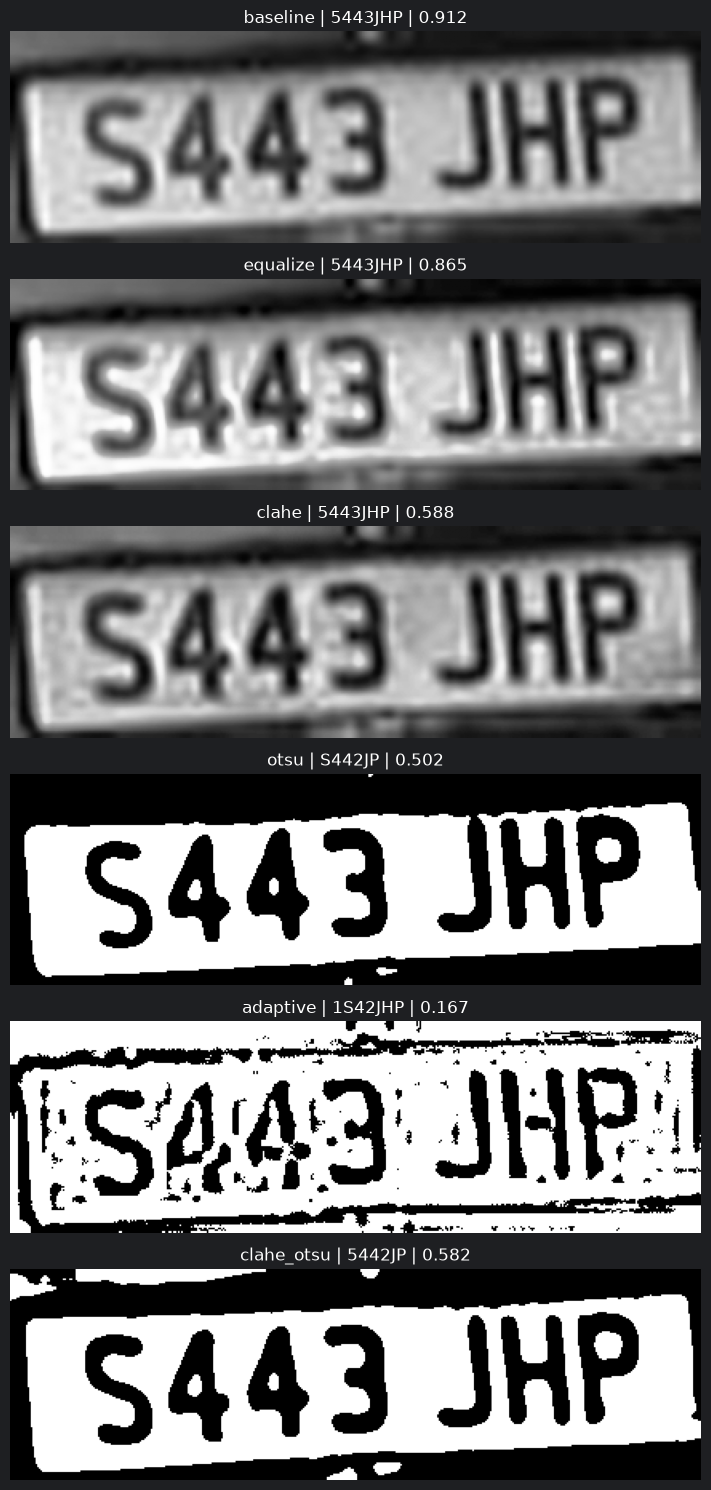

In [17]:
fig, ax = plt.subplots(
    len(methods),
    1,
    figsize=(10, 2.5 * len(methods))
)

for i, method in enumerate(methods):
    processed = preprocess_plate(
        plate,
        method=method
    )

    text, conf = recognize_plate(
        processed,
        reader
    )

    ax[i].imshow(
        processed,
        cmap="gray"
    )

    ax[i].set_title(
        f"{method} | {text} | {conf:.3f}"
    )

    ax[i].axis("off")

plt.tight_layout()

plt.show()

In [ ]:
fig, ax = plt.subplots(
    1,
    3,
    figsize=(15,5)
)

ax[0].imshow(cv2.cvtColor(cv2.imread(image_path),cv2.COLOR_BGR2RGB))
ax[0].set_title("Original")

ax[1].imshow(plate)
ax[1].set_title("Detected plate")

ax[2].imshow(processed,cmap="gray")
ax[2].set_title(f"{text}\n{confidence:.3f}")

for a in ax:
    a.axis("off")

plt.tight_layout()